# IPL Player Auction Price Prediction — Machine Learning Project
**Dataset:** `IPL_Auction_Player_Performance_Analytics.csv`

_____

### Problem Statement
In the IPL, franchises invest heavily in players during auctions. Deciding how much a player is worth is complex and depends on past performance, experience, and skills.

**Business Question:** Can we predict a player's auction price based on their historical performance and attributes?

# **SPRINT 1: DATA UNDERSTANDING & PREPROCESSING**
- Goal: Convert raw data → clean, meaningful, model-ready dataset

## Step 1: Data Collection & Loading

In [62]:
# Import the core libraries we need for this project
import pandas as pd                
import numpy as np                  
import matplotlib.pyplot as plt     
import seaborn as sns               
import warnings

warnings.filterwarnings('ignore')   
sns.set_style('whitegrid')   

In [63]:
# Load the dataset from the CSV file
df = pd.read_csv('IPL_Auction_Player_Performance_Analytics.csv')

## Step 2: Initial Data Inspection

In [64]:
df.head()

,Name,Age,Country,Role,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price ( in Cr )
0,MS Dhoni,42,India,Wicketkeeper,350,20,12000,135.0,0,0.00,50.00,CSK,20.0
1,Sachin Tendulkar,45,India,Batter,400,24,18000,125.0,5,8.50,45.00,MI,1.5
2,Virat Kohli,36,India,Batter,300,16,13000,138.0,2,7.00,52.00,RCB,18.0
3,Rohit Sharma,37,India,Batter,280,17,14000,132.0,0,8.00,48.00,MI,18.0
4,Jasprit Bumrah,35,India,Bowler,196,7,2661,144.9,798,7.69,27.43,MI,12.0


In [65]:
df.tail()

,Name,Age,Country,Role,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price ( in Cr )
11995,Aravinda de Silva,29,Sri Lanka,Batter,22,1,14111,136.0,11,8.87,35.83,DC,12.0
11996,Inzamam-ul-Haq,26,Pakistan,Batter,72,4,9945,104.1,12,6.87,36.04,PBKS,0.2
11997,Javed Miandad,29,Pakistan,Batter,153,9,12993,106.3,7,9.10,39.90,KKR,12.0
11998,Saqlain Mushtaq,23,Pakistan,Bowler,27,1,1771,133.2,544,7.65,35.40,RR,0.2
11999,Shahid Afridi,38,Pakistan,Allrounder,102,6,4980,144.5,127,7.51,40.67,SRH,10.0


In [66]:
# .info() tells us the data type of every column and whether it has missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Name                     12000 non-null  object 
 1   Age                      12000 non-null  int64  
 2   Country                  12000 non-null  object 
 3   Role                     12000 non-null  object 
 4   Matches                  12000 non-null  int64  
 5   Experience ( in Yrs)     12000 non-null  int64  
 6   Runs                     12000 non-null  int64  
 7   Strike_Rate              12000 non-null  float64
 8   Wickets                  12000 non-null  int64  
 9   Economy                  12000 non-null  float64
 10  Average                  12000 non-null  float64
 11  Team_Preference          12000 non-null  object 
 12  Auction_Price ( in Cr )  12000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 1.2+ MB


In [67]:
# .describe() gives statistical summary (mean, min, max, etc.) for numeric columns
df.describe()

,Age,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Auction_Price ( in Cr )
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,30.094667,146.447167,6.523083,5897.813833,125.118867,191.803500,5.068873,37.386248,3.729067
std,7.191883,125.774590,5.361237,3630.126361,17.270469,246.319993,3.167495,10.094644,3.693414
min,18.000000,15.000000,1.000000,0.000000,95.000000,0.000000,0.000000,20.000000,0.200000
25%,24.000000,46.000000,2.000000,2986.750000,110.300000,0.000000,0.000000,28.570000,1.000000
50%,30.000000,108.000000,5.000000,5359.500000,125.200000,15.000000,6.220000,37.340000,2.000000
75%,36.000000,217.000000,10.000000,8450.250000,140.100000,351.000000,7.420000,46.092500,5.000000
max,45.000000,713.000000,24.000000,18000.000000,155.000000,900.000000,9.500000,55.000000,20.000000


In [68]:
df.dtypes

Name                        object
Age                          int64
Country                     object
Role                        object
Matches                      int64
Experience ( in Yrs)         int64
Runs                         int64
Strike_Rate                float64
Wickets                      int64
Economy                    float64
Average                    float64
Team_Preference             object
Auction_Price ( in Cr )    float64
dtype: object

In [69]:
# Checking missing values 
df.isnull().sum()

Name                       0
Age                        0
Country                    0
Role                       0
Matches                    0
Experience ( in Yrs)       0
Runs                       0
Strike_Rate                0
Wickets                    0
Economy                    0
Average                    0
Team_Preference            0
Auction_Price ( in Cr )    0
dtype: int64

In [70]:
# Unique value check
print(df['Country'].unique())

['India' 'South Africa' 'West Indies' 'Australia' 'Afghanistan'
 'New Zealand' 'England' 'Sri Lanka' 'Pakistan']


In [71]:
print(df['Role'].unique())

['Wicketkeeper' 'Batter' 'Bowler' 'Allrounder']


In [72]:
print(df['Team_Preference'].unique())

['CSK' 'MI' 'RCB' 'RR' 'KKR' 'DC' 'PBKS' 'SRH' 'GT' 'LSG' 'PWI']


In [73]:
# Check Duplicates In Data
df.duplicated().sum()

np.int64(0)

## Step 3: Data Cleaning

In [74]:
# Handel missing values if any existed
df.isnull().sum()

Name                       0
Age                        0
Country                    0
Role                       0
Matches                    0
Experience ( in Yrs)       0
Runs                       0
Strike_Rate                0
Wickets                    0
Economy                    0
Average                    0
Team_Preference            0
Auction_Price ( in Cr )    0
dtype: int64

In [75]:
# Remove duplicate rows (if any)
df.duplicated().sum()

np.int64(0)

In [76]:
# Standardize column names
df.head(2)

,Name,Age,Country,Role,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price ( in Cr )
0,MS Dhoni,42,India,Wicketkeeper,350,20,12000,135.0,0,0.0,50.0,CSK,20.0
1,Sachin Tendulkar,45,India,Batter,400,24,18000,125.0,5,8.5,45.0,MI,1.5


In [77]:
df = df.rename(columns={
    'Experience ( in Yrs)':'Experince_Years',
    'Auction_Price ( in Cr )': 'Auction_Price_Cr'
})

In [78]:
# Confirm data types are correct after cleaning
df.dtypes

Name                 object
Age                   int64
Country              object
Role                 object
Matches               int64
Experince_Years       int64
Runs                  int64
Strike_Rate         float64
Wickets               int64
Economy             float64
Average             float64
Team_Preference      object
Auction_Price_Cr    float64
dtype: object

In [79]:
# Preview the cleaned dataframe
df.sample(5)

,Name,Age,Country,Role,Matches,Experince_Years,Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price_Cr
10671,Sameer Khan,30,Australia,Wicketkeeper,29,1,3118,116.7,0,0.00,37.24,MI,5.0
7585,Irfan Patel,34,Sri Lanka,Wicketkeeper,137,9,8062,97.3,0,0.00,50.71,KKR,0.2
1154,Nikhil Sharma,39,England,Wicketkeeper,220,13,2550,110.6,0,0.00,25.58,DC,7.0
5476,Aditya Patel,41,England,Batter,198,8,13275,147.2,13,7.73,47.16,PBKS,5.0
9494,Rohan Mehta,32,South Africa,Batter,157,8,5339,134.2,7,7.61,42.70,LSG,0.2


## Step 4: Exploratory Data Analysis (EDA)

### Univariate Analysis

In [80]:
# Distribution plots for all numeric columns (histograms)
numerical_cols = ['Age', 'Matches', 'Experince_Years', 'Runs', 'Strike_Rate', 'Wickets', 'Economy', 'Average', 'Auction_Price_Cr']

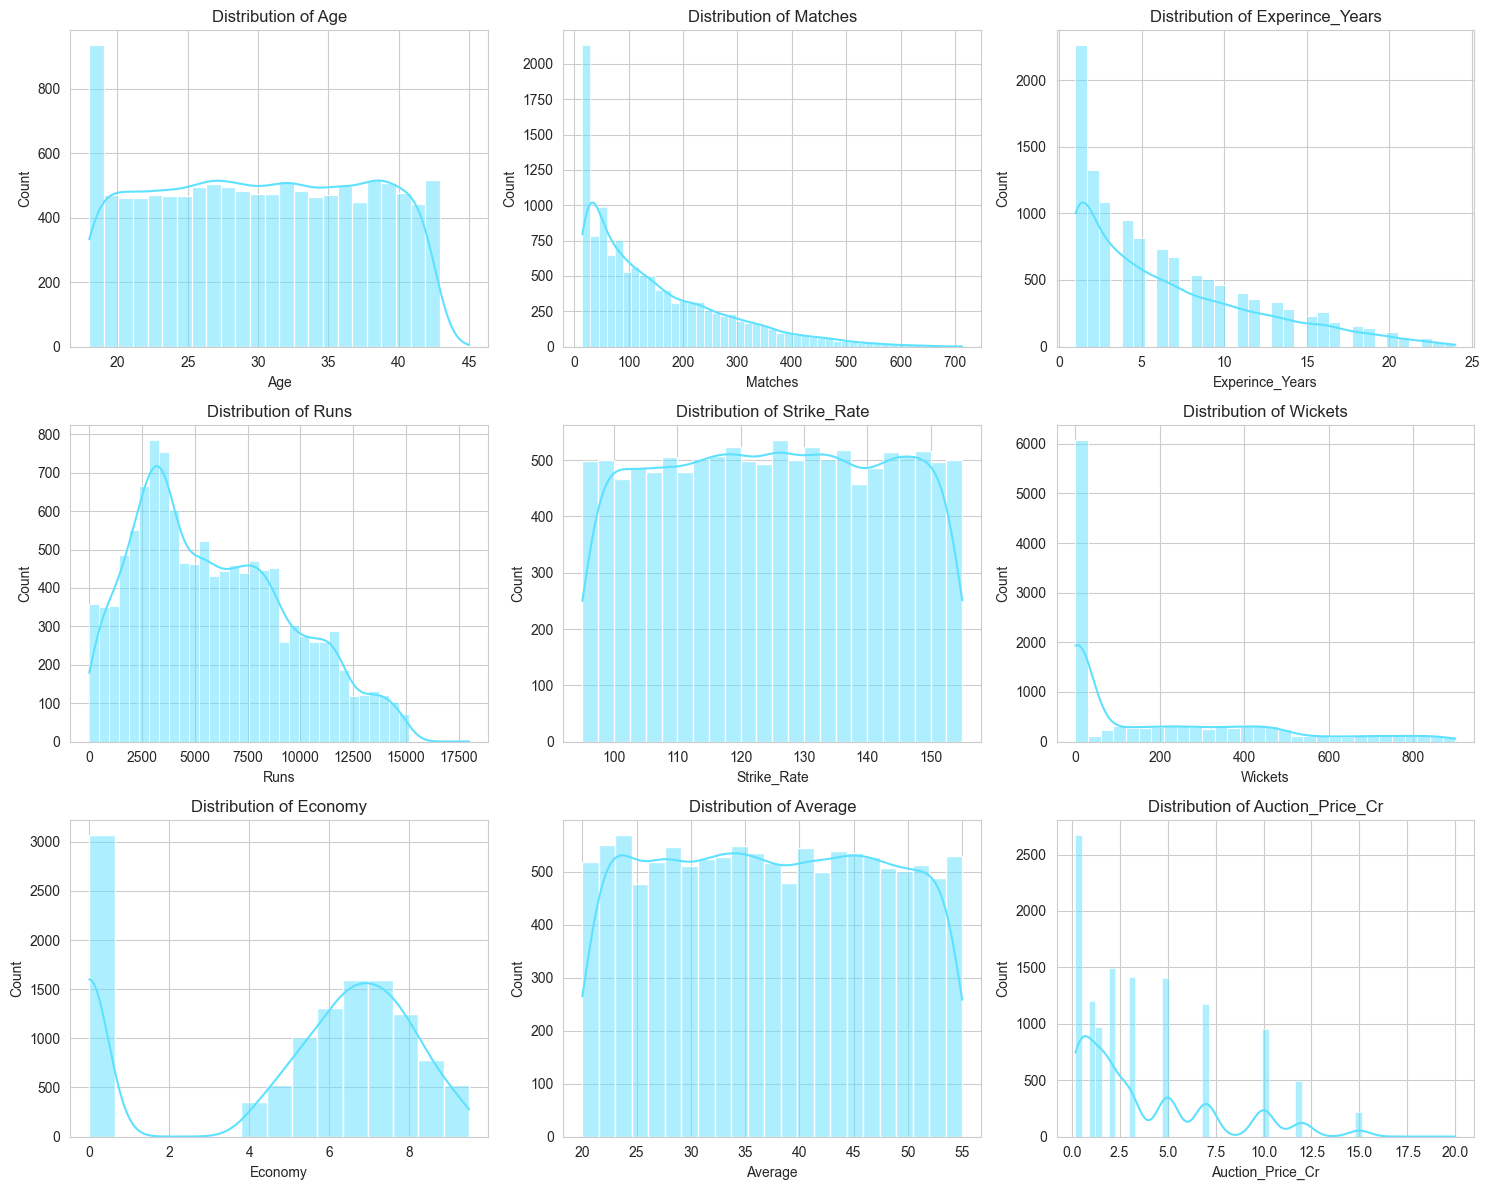

In [81]:
fig, axes = plt.subplots(3,3, figsize=(15,12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color='#5EE1FF')
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [82]:
# Check skewness of numeric columns
print(df[numerical_cols].skew().sort_values(ascending=False))

Auction_Price_Cr    1.201364
Matches             1.198591
Wickets             1.164379
Experince_Years     0.993893
Runs                0.479362
Average             0.011310
Strike_Rate        -0.008780
Age                -0.013877
Economy            -0.727076
dtype: float64


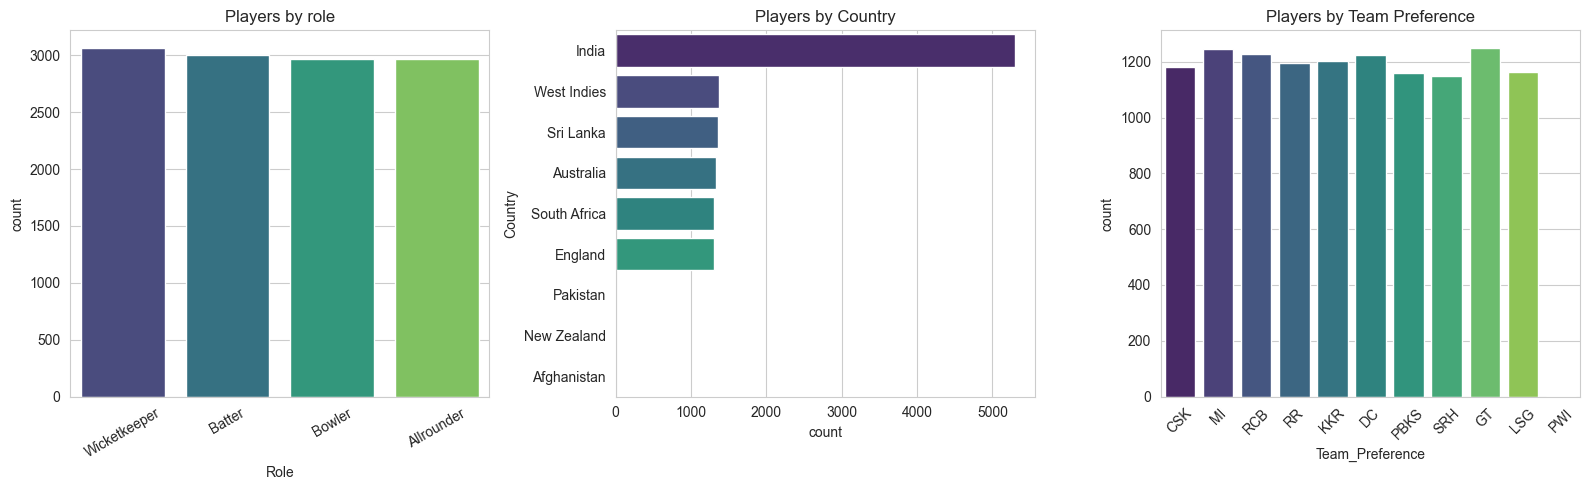

In [83]:
# Countplot for categorical columns - Hom many players fall in each category 
fig, axes = plt.subplots(1,3, figsize=(16,5))


sns.countplot(data=df, x='Role', ax=axes[0], palette='viridis')
axes[0].set_title('Players by role')
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(data=df, y='Country', ax=axes[1], palette='viridis', order=df['Country'].value_counts().index)
axes[1].set_title('Players by Country')

sns.countplot(data=df, x='Team_Preference', ax=axes[2], palette='viridis')
axes[2].set_title('Players by Team Preference')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Bivariate Analysis

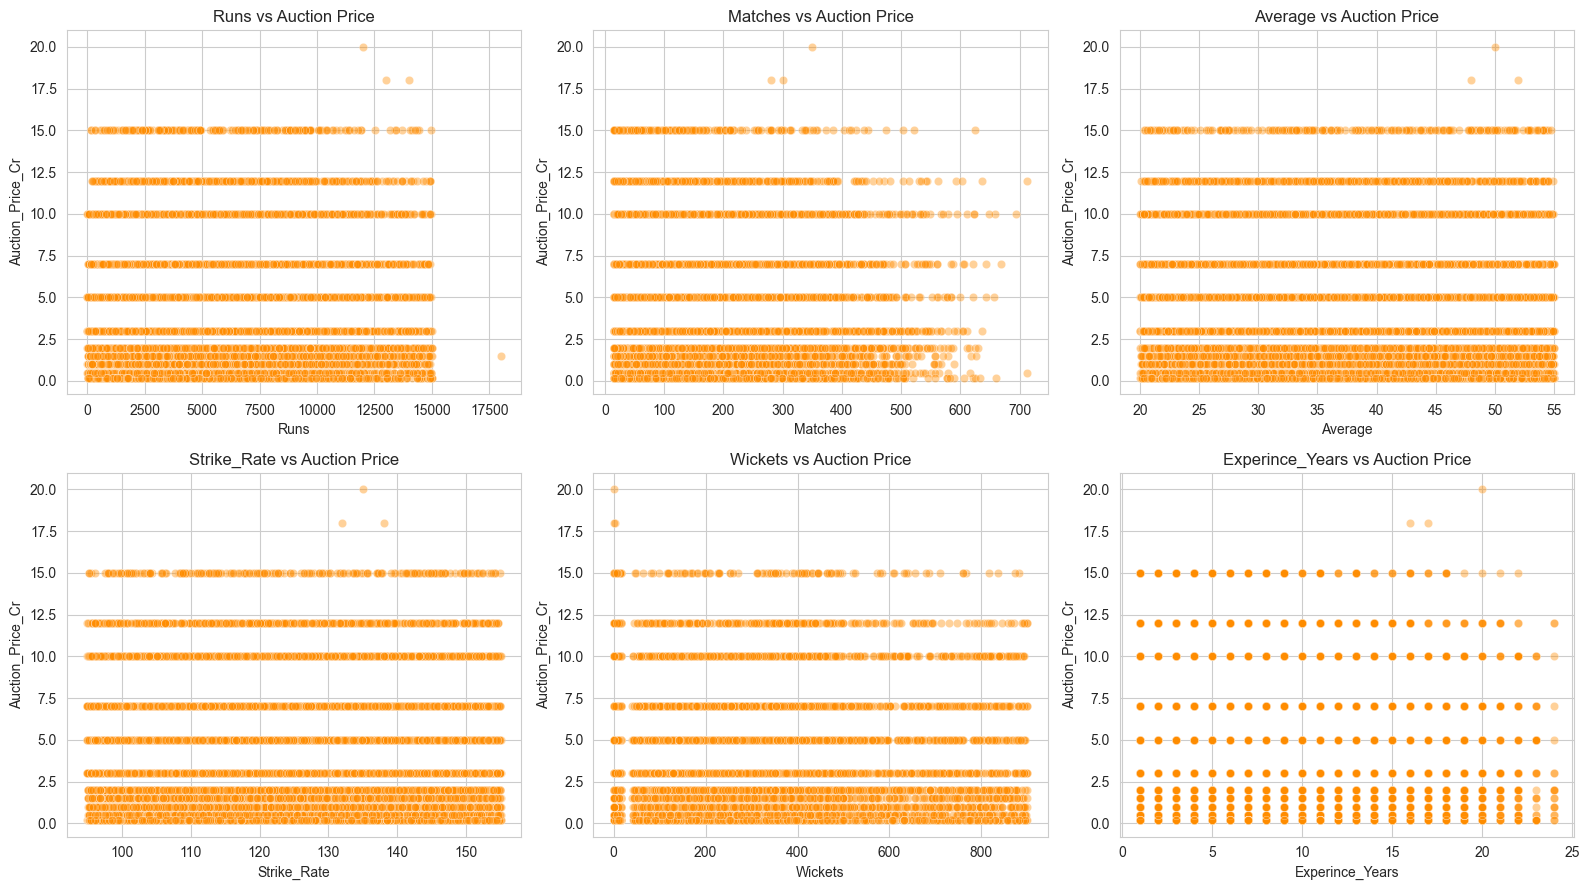

In [84]:
# Scatter plots: feature vs target, to visually spot relationships
features_to_check = ['Runs', 'Matches', 'Average', 'Strike_Rate', 'Wickets', 'Experince_Years']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(features_to_check):
    sns.scatterplot(data=df, x=col, y='Auction_Price_Cr', ax=axes[i], alpha=0.4, color='darkorange')
    axes[i].set_title(f'{col} vs Auction Price')

plt.tight_layout()
plt.show()

Correlation with Auction_Price_Cr:
Auction_Price_Cr    1.000000
Runs                0.007932
Age                 0.007616
Economy             0.004957
Experince_Years     0.004502
Matches             0.004371
Wickets            -0.000665
Strike_Rate        -0.003833
Average            -0.007938
Name: Auction_Price_Cr, dtype: float64


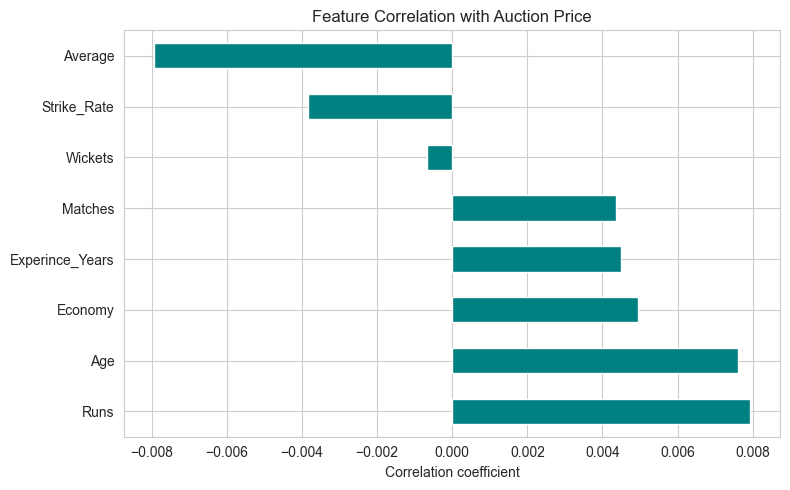

In [85]:
# Correlation of every numeric feature with the target variable
correlation_with_target = df[numerical_cols].corr()['Auction_Price_Cr'].sort_values(ascending=False)

print("Correlation with Auction_Price_Cr:")
print(correlation_with_target)

plt.figure(figsize=(8, 5))
correlation_with_target.drop('Auction_Price_Cr').plot(kind='barh', color='teal')
plt.title('Feature Correlation with Auction Price')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

### Multivariate Analysis


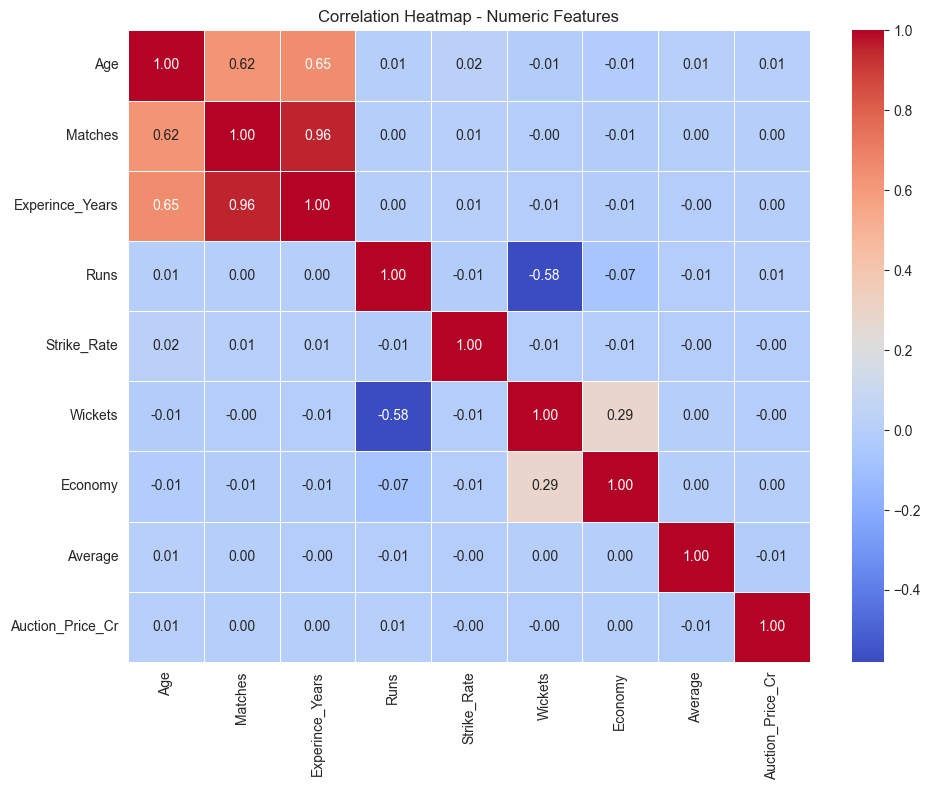

In [86]:
# Correlation heatmap - shows relationships between ALL numeric columns at once
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

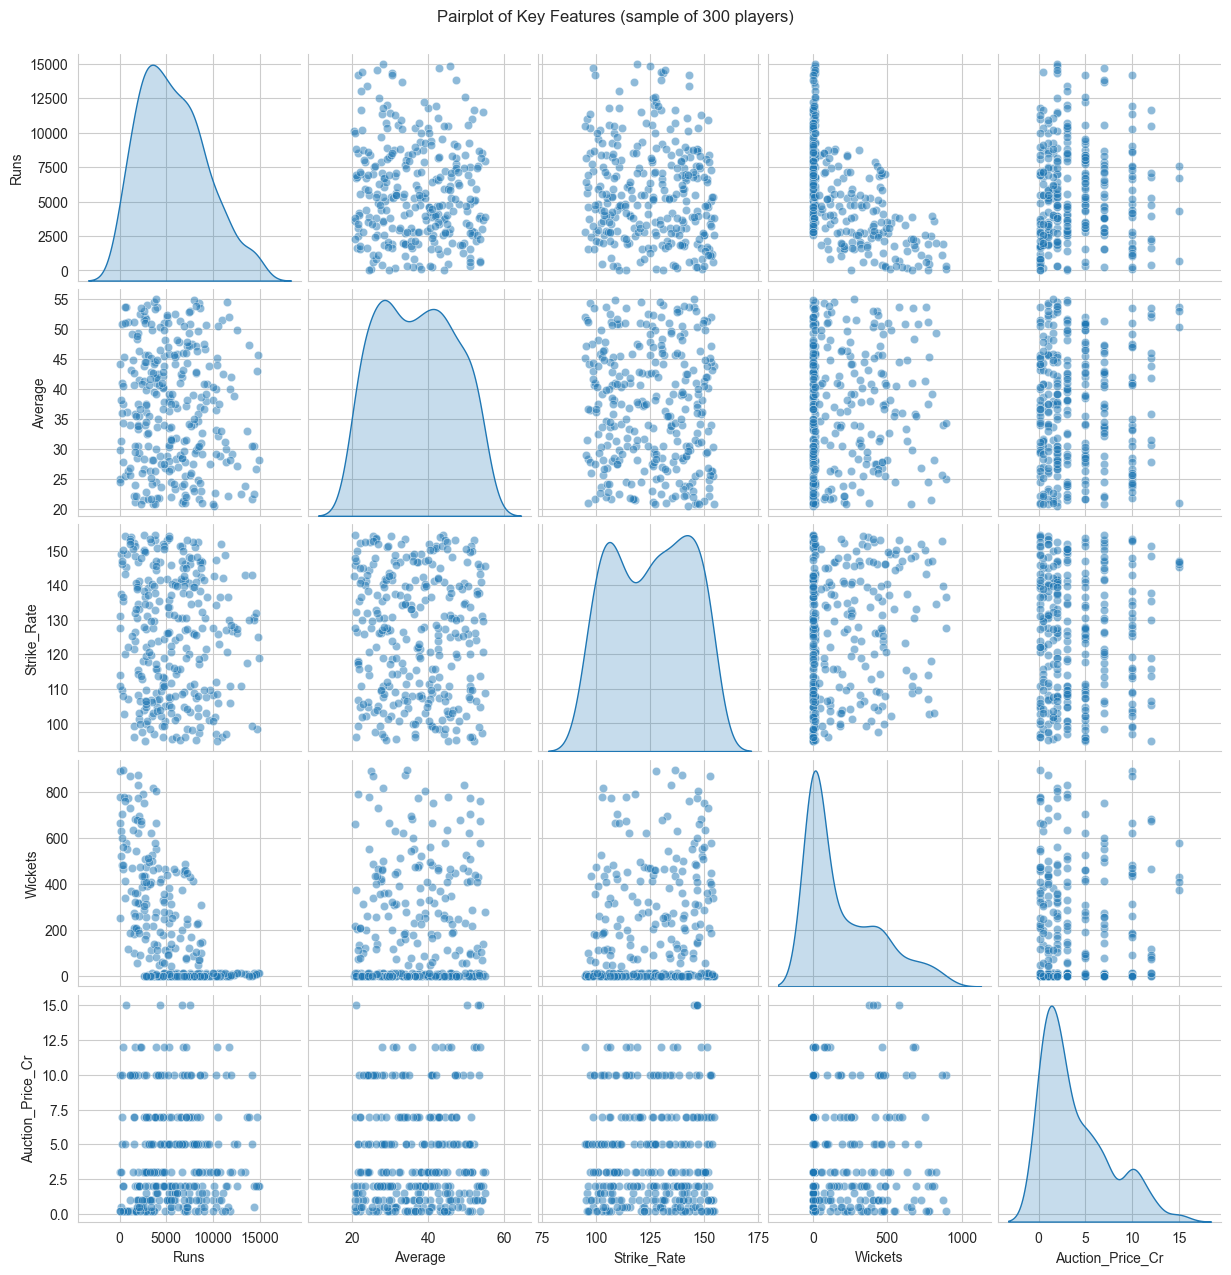

In [87]:
# Pairplot to see interaction effects between key features
sample_df = df.sample(300, random_state=42)
key_cols = ['Runs', 'Average', 'Strike_Rate', 'Wickets', 'Auction_Price_Cr']

sns.pairplot(sample_df[key_cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Key Features (sample of 300 players)', y=1.02)
plt.show()

## Step 5: Outlier Detection & Treatment


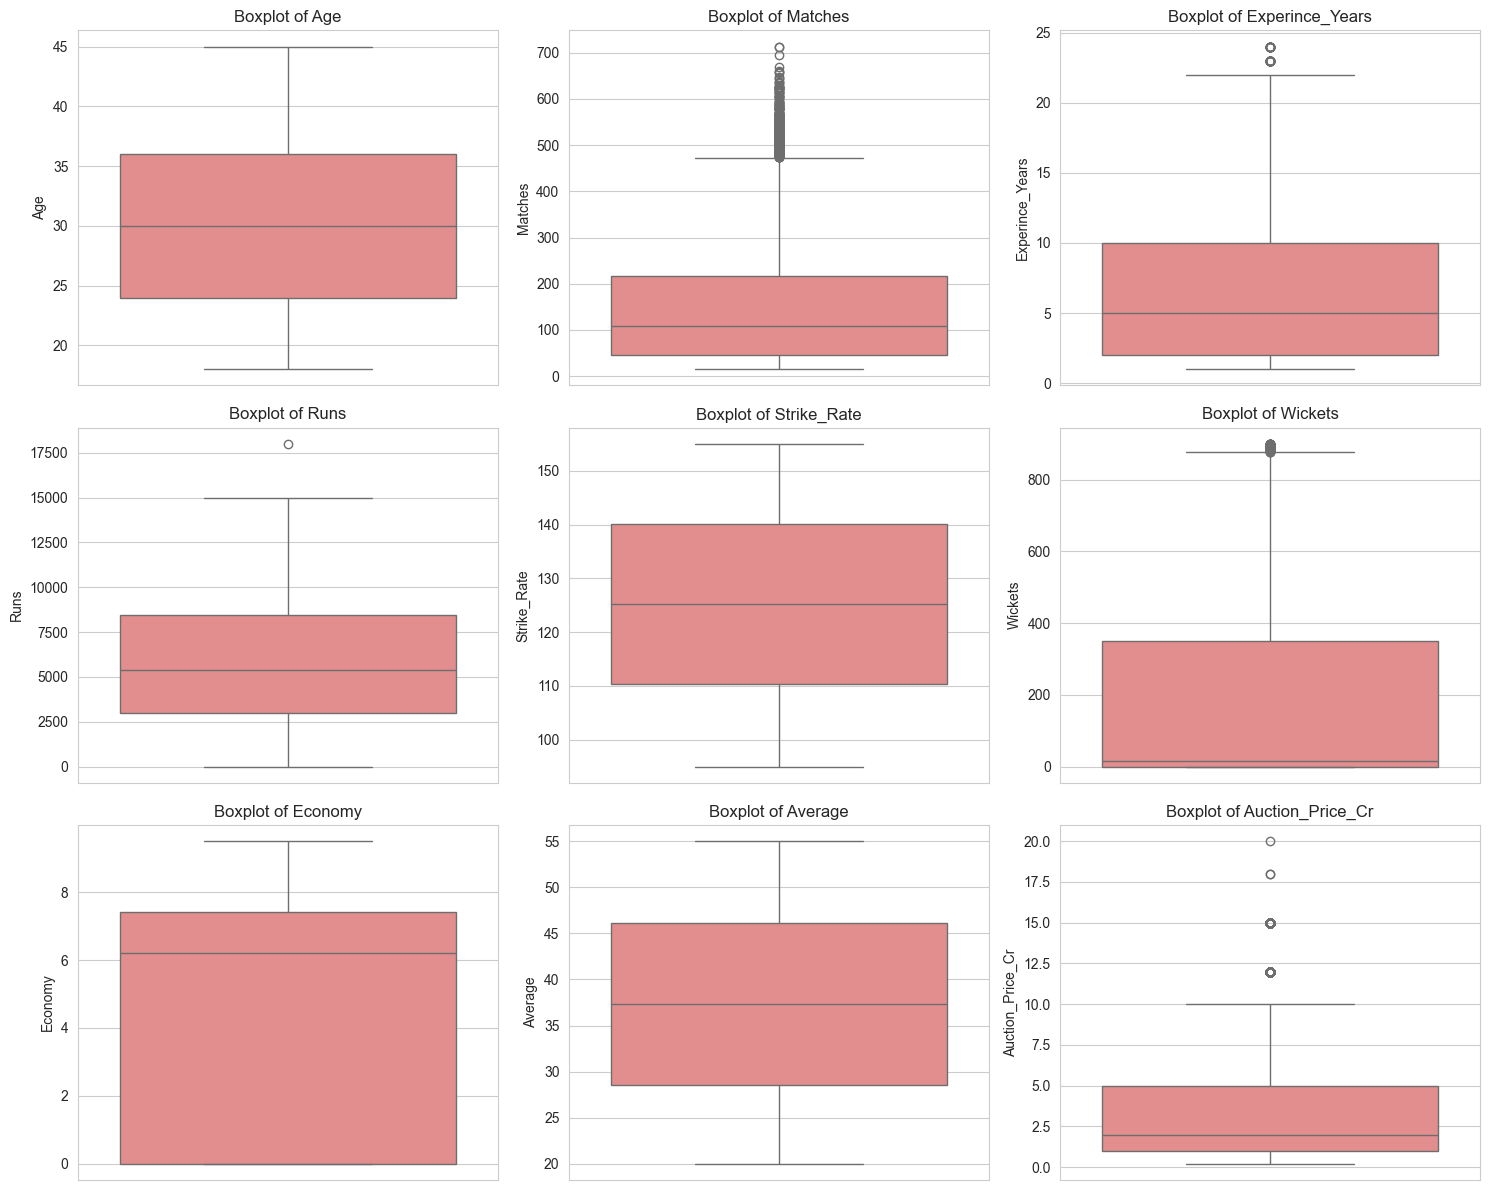

In [88]:
# Boxplots to visually spot outliers in numeric columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [89]:
# IQR-based outlier detection function
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Outlier count per numeric column (IQR method):")
for col in numerical_cols:
    count, low, high = count_outliers_iqr(df, col)
    print(f"  {col}: {count} outliers  (valid range: {low:.2f} to {high:.2f})")

Outlier count per numeric column (IQR method):
  Age: 0 outliers  (valid range: 6.00 to 54.00)
  Matches: 266 outliers  (valid range: -210.50 to 473.50)
  Experince_Years: 56 outliers  (valid range: -10.00 to 22.00)
  Runs: 1 outliers  (valid range: -5208.50 to 16645.50)
  Strike_Rate: 0 outliers  (valid range: 65.60 to 184.80)
  Wickets: 83 outliers  (valid range: -526.50 to 877.50)
  Economy: 0 outliers  (valid range: -11.13 to 18.55)
  Average: 0 outliers  (valid range: 2.29 to 72.38)
  Auction_Price_Cr: 710 outliers  (valid range: -5.00 to 11.00)


In [90]:
# Treat outliers by CAPPING them to the IQR bounds instead of deleting rows
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = np.clip(data[column], lower_bound, upper_bound)
    return data

for col in numerical_cols:
    df = cap_outliers_iqr(df, col)

print("Outliers capped. Re-checking counts:")
for col in numerical_cols:
    count, low, high = count_outliers_iqr(df, col)
    print(f"  {col}: {count} outliers remaining")

Outliers capped. Re-checking counts:
  Age: 0 outliers remaining
  Matches: 0 outliers remaining
  Experince_Years: 0 outliers remaining
  Runs: 0 outliers remaining
  Strike_Rate: 0 outliers remaining
  Wickets: 0 outliers remaining
  Economy: 0 outliers remaining
  Average: 0 outliers remaining
  Auction_Price_Cr: 0 outliers remaining


## Step 6: Feature Encoding


In [91]:
df.head(3)

,Name,Age,Country,Role,Matches,Experince_Years,Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price_Cr
0,MS Dhoni,42,India,Wicketkeeper,350.0,20,12000.0,135.0,0.0,0.0,50.0,CSK,11.0
1,Sachin Tendulkar,45,India,Batter,400.0,22,16645.5,125.0,5.0,8.5,45.0,MI,1.5
2,Virat Kohli,36,India,Batter,300.0,16,13000.0,138.0,2.0,7.0,52.0,RCB,11.0


In [92]:
# Drop the 'Name' column - it's an identifier, not a useful predictor
df_model = df.drop(columns=['Name'])

In [93]:
df_model.shape

(12000, 12)

In [94]:
# One-Hot Encode the categorical columns
# `Role`, `Country`, `Team_Preference` are **nominal** categories (no natural order) → we use **One-Hot Encoding**.
df_model = pd.get_dummies(df_model, columns=['Role', 'Country', 'Team_Preference'], drop_first=True)
print(df_model.shape)

(12000, 30)


In [95]:
# Full encoded data 
df_model.head()

,Age,Matches,Experince_Years,Runs,Strike_Rate,Wickets,Economy,Average,Auction_Price_Cr,Role_Batter,...,Team_Preference_DC,Team_Preference_GT,Team_Preference_KKR,Team_Preference_LSG,Team_Preference_MI,Team_Preference_PBKS,Team_Preference_PWI,Team_Preference_RCB,Team_Preference_RR,Team_Preference_SRH
0,42,350.0,20,12000.0,135.0,0.0,0.00,50.00,11.0,False,...,False,False,False,False,False,False,False,False,False,False
1,45,400.0,22,16645.5,125.0,5.0,8.50,45.00,1.5,True,...,False,False,False,False,True,False,False,False,False,False
2,36,300.0,16,13000.0,138.0,2.0,7.00,52.00,11.0,True,...,False,False,False,False,False,False,False,True,False,False
3,37,280.0,17,14000.0,132.0,0.0,8.00,48.00,11.0,True,...,False,False,False,False,True,False,False,False,False,False
4,35,196.0,7,2661.0,144.9,798.0,7.69,27.43,11.0,False,...,False,False,False,False,True,False,False,False,False,False


## Step 7 & 8: Feature Scaling and Train-Test Split


In [96]:
# Separate features (X) and target (y)
X = df_model.drop(columns=['Auction_Price_Cr'])
y = df_model['Auction_Price_Cr']

print("Feature shape", X.shape)
print("Target Shape", y.shape)

Feature shape (12000, 29)
Target Shape (12000,)


In [97]:
# Train-Test split: 80% training, 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print("Training Dataset shape", X_train.shape)
print("Testing Dataset Shape", X_test.shape)

Training Dataset shape (9600, 29)
Testing Dataset Shape (2400, 29)


In [98]:
# Feature Scaling using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [100]:
X_train_scaled.head()

,Age,Matches,Experince_Years,Runs,Strike_Rate,Wickets,Economy,Average,Role_Batter,Role_Bowler,...,Team_Preference_DC,Team_Preference_GT,Team_Preference_KKR,Team_Preference_LSG,Team_Preference_MI,Team_Preference_PBKS,Team_Preference_PWI,Team_Preference_RCB,Team_Preference_RR,Team_Preference_SRH
9182,-1.546303,-0.966661,-1.035621,-0.884003,-0.409130,0.611492,0.429390,-1.696538,-0.577831,1.739783,...,-0.33449,-0.338518,-0.332754,-0.326149,2.900304,-0.328295,0.0,-0.340616,-0.329073,-0.326344
11091,0.678698,0.766977,0.459074,1.330552,-0.525108,-0.780375,-1.604714,0.082230,-0.577831,-0.574784,...,-0.33449,-0.338518,3.005220,-0.326149,-0.344791,-0.328295,0.0,-0.340616,-0.329073,-0.326344
6428,0.817760,1.605039,1.766932,0.382682,-1.296359,0.736922,0.698284,0.035629,-0.577831,-0.574784,...,-0.33449,-0.338518,-0.332754,-0.326149,-0.344791,-0.328295,0.0,-0.340616,-0.329073,-0.326344
288,-1.685365,-0.958445,-1.035621,-0.517076,-0.130784,-0.290794,0.419899,1.565529,-0.577831,-0.574784,...,-0.33449,-0.338518,-0.332754,-0.326149,-0.344791,-0.328295,0.0,-0.340616,-0.329073,-0.326344
2626,-0.433803,0.208269,0.272237,-0.587310,-0.264158,-0.464778,1.027284,-1.688606,-0.577831,-0.574784,...,-0.33449,-0.338518,-0.332754,-0.326149,-0.344791,3.046042,0.0,-0.340616,-0.329073,-0.326344


____

# **SPRINT 2: MODEL BUILDING & EVALUATION**
- Goal: Build baseline and compare multiple models

## Step 1: Baseline Model

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [102]:
results = []
trained_model = {}

def evaluate_model(name, y_true, y_pred, store=True):
    mae =mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"--{name}--")
    print(f"MAE : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R2 : {r2:.3f}")

    if store :
        results.append({"Model":name, "MAE" : mae, 'RMSE': rmse, 'R2': r2})
    return mae, r2, rmse

In [103]:
# Train baseline model with help of LinearRegression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
trained_model['Linear Regression'] = lr_model

In [104]:
# Evaluate the baseline model on the test set
y_pred_lr = lr_model.predict(X_test_scaled)
evaluate_model('Linear Regression', y_test, y_pred_lr)

--Linear Regression--
MAE : 2.837
RMSE : 3.373
R2 : -0.002


(2.836932713445974, -0.002459831024589354, np.float64(3.3730258877849906))

_____

# **SPRINT 3: OPTIMIZATION & FINAL MODEL**
- Goal: Improve model performance and reliability

In [105]:
df.head()

,Name,Age,Country,Role,Matches,Experince_Years,Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price_Cr
0,MS Dhoni,42,India,Wicketkeeper,350.0,20,12000.0,135.0,0.0,0.00,50.00,CSK,11.0
1,Sachin Tendulkar,45,India,Batter,400.0,22,16645.5,125.0,5.0,8.50,45.00,MI,1.5
2,Virat Kohli,36,India,Batter,300.0,16,13000.0,138.0,2.0,7.00,52.00,RCB,11.0
3,Rohit Sharma,37,India,Batter,280.0,17,14000.0,132.0,0.0,8.00,48.00,MI,11.0
4,Jasprit Bumrah,35,India,Bowler,196.0,7,2661.0,144.9,798.0,7.69,27.43,MI,11.0


In [107]:
# Create new domain-driven features
df_fe = df.drop(columns=['Name']).copy()
df_fe['Runs_per_match'] = df_fe['Runs'] / df_fe['Matches']
df_fe['Wikects_per_match'] = df_fe['Wickets'] / df_fe['Matches']
df_fe['Experience_ratio'] = df_fe['Experince_Years'] / df_fe['Age']

df_fe[['Runs_per_match', 'Wikects_per_match', 'Experience_ratio']].head()

,Runs_per_match,Wikects_per_match,Experience_ratio
0,34.285714,0.000000,0.476190
1,41.613750,0.012500,0.488889
2,43.333333,0.006667,0.444444
3,50.000000,0.000000,0.459459
4,13.576531,4.071429,0.200000


In [108]:
# One-Hot Encode categorical columns again (same as Sprint 1, Step 6)
df_fe = pd.get_dummies(df_fe, columns=['Role', 'Country', 'Team_Preference'], drop_first=True)

print("Shape after feature engineering + encoding:", df_fe.shape)

Shape after feature engineering + encoding: (12000, 33)


## Step 2: Feature Selection

In [113]:
# Correlation of ALL features 
new_feature_corr = df_fe.corr()['Auction_Price_Cr'].sort_values(ascending=False)
print("Top 15 features most correlated with Auction Price:")
print(new_feature_corr.head(15))

Top 15 features most correlated with Auction Price:
Auction_Price_Cr       1.000000
Country_New Zealand    0.014888
Team_Preference_KKR    0.012385
Team_Preference_DC     0.011143
Team_Preference_LSG    0.007426
Runs                   0.007036
Age                    0.006678
Runs_per_match         0.006352
Economy                0.005784
Country_India          0.004570
Country_Sri Lanka      0.004299
Experince_Years        0.004292
Role_Bowler            0.003851
Wikects_per_match      0.002686
Matches                0.002213
Name: Auction_Price_Cr, dtype: float64


In [110]:
# Re-split and re-scale the enhanced dataset (needed because we added new columns)
X_fe = df_fe.drop(columns=['Auction_Price_Cr'])
y_fe = df_fe['Auction_Price_Cr']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)

scaler_fe = StandardScaler()
X_train_fe_scaled = pd.DataFrame(scaler_fe.fit_transform(X_train_fe), columns=X_train_fe.columns, index=X_train_fe.index)
X_test_fe_scaled = pd.DataFrame(scaler_fe.transform(X_test_fe), columns=X_test_fe.columns, index=X_test_fe.index)

print("Enhanced training set shape:", X_train_fe_scaled.shape)

Enhanced training set shape: (9600, 32)


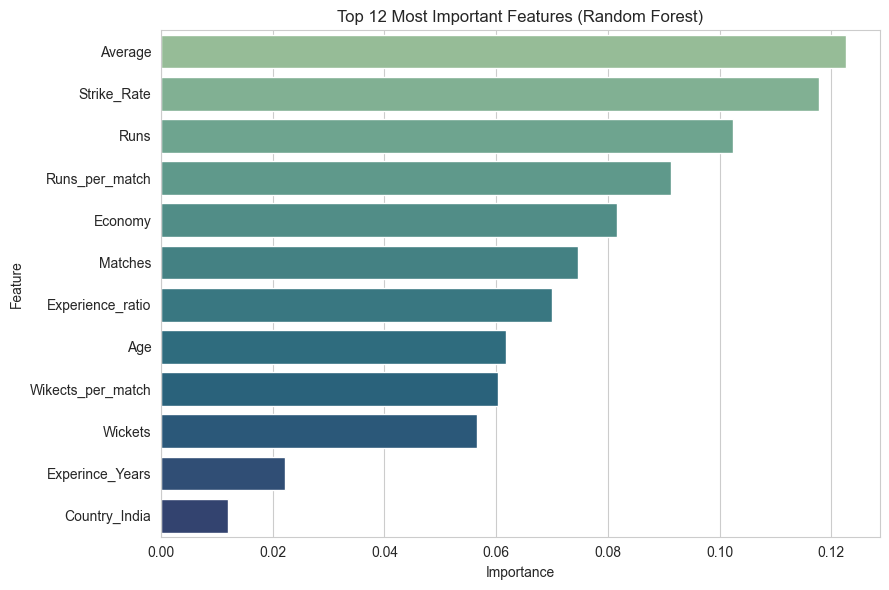

In [112]:
# Feature importance from a Random Forest - which features matter most?
from sklearn.ensemble import RandomForestRegressor
rf_for_importance = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_for_importance.fit(X_train_fe_scaled, y_train_fe)

importance_df = pd.DataFrame({
    'Feature': X_train_fe_scaled.columns,
    'Importance': rf_for_importance.feature_importances_
}).sort_values(by='Importance', ascending=False).head(12)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='crest')
plt.title('Top 12 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()

## Step 3: Hyperparameter Tuning


In [114]:
# Hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [8, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_fe_scaled, y_train_fe)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation R2 score:", round(grid_search.best_score_, 3))

Best parameters found: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 150}
Best cross-validation R2 score: -0.011


## Step 4: Build Final Model

In [115]:
# Train the final model using the best hyperparameters found above
final_model = RandomForestRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)
final_model.fit(X_train_fe_scaled, y_train_fe)

print("Final tuned model trained.")

Final tuned model trained.


## Step 5: Final Evaluation

In [116]:
# Evaluate the final model on unseen test data
y_pred_final = final_model.predict(X_test_fe_scaled)
evaluate_model('Final Tuned Random Forest', y_test_fe, y_pred_final, store=False)

--Final Tuned Random Forest--
MAE : 2.841
RMSE : 3.380
R2 : -0.007


(2.8409702191805684, -0.006818054341178437, np.float64(3.3803501000128646))

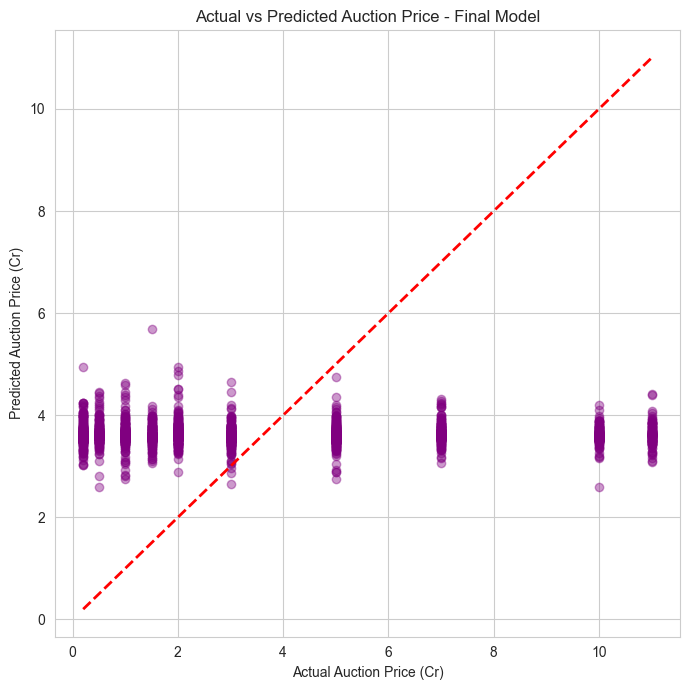

In [117]:
# Visualize: Actual vs Predicted auction prices
plt.figure(figsize=(7, 7))
plt.scatter(y_test_fe, y_pred_final, alpha=0.4, color='purple')
plt.plot([y_test_fe.min(), y_test_fe.max()], [y_test_fe.min(), y_test_fe.max()], 'r--', lw=2)
plt.xlabel('Actual Auction Price (Cr)')
plt.ylabel('Predicted Auction Price (Cr)')
plt.title('Actual vs Predicted Auction Price - Final Model')
plt.tight_layout()
plt.show()

## Step 6: Model Serialization

In [118]:
# Save the final model and the scaler to disk so they can be reused later (e.g. in a deployed app)
import joblib

joblib.dump(final_model, 'ipl_auction_price_model.pkl')
joblib.dump(scaler_fe, 'ipl_auction_price_scaler.pkl')

print("Model saved as: ipl_auction_price_model.pkl")
print("Scaler saved as: ipl_auction_price_scaler.pkl")

Model saved as: ipl_auction_price_model.pkl
Scaler saved as: ipl_auction_price_scaler.pkl


__________

# **SPRINT 4: DEPLOYMENT**
**Goal:** Make the model usable in a real-world application

## Step 1: Build ML Pipeline
For deployment, it's best practice to bundle preprocessing (scaling) and the model into a **single object** — so a user never has to remember "first scale, then predict" as two separate steps.

In [119]:
# Combine scaling + model into a single deployable sklearn Pipeline
from sklearn.pipeline import Pipeline

deployment_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1))
])

# Fit the pipeline directly on the RAW (unscaled) engineered features
deployment_pipeline.fit(X_train_fe, y_train_fe)

# Quick sanity check - should give a very similar R2 to our final model above
pipeline_pred = deployment_pipeline.predict(X_test_fe)
print("Deployment Pipeline R2 on test data:", round(r2_score(y_test_fe, pipeline_pred), 3))

Deployment Pipeline R2 on test data: -0.007


In [120]:
# Save the complete pipeline as ONE file - this is what a deployed app will load
joblib.dump(deployment_pipeline, 'ipl_auction_price_pipeline.pkl')
print("Full deployment pipeline saved as: ipl_auction_price_pipeline.pkl")

Full deployment pipeline saved as: ipl_auction_price_pipeline.pkl


## Step 2: Frontend (Streamlit App)
A notebook can't run an interactive web app, so the Streamlit code below is written out to a separate file, `app.py`, using the `%%writefile` magic command. Run this app **outside** the notebook (see Step 3).

In [122]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load the saved deployment pipeline (scaler + model bundled together)
pipeline = joblib.load('ipl_auction_price_pipeline.pkl')

st.title('IPL Player Auction Price Predictor')
st.write('Enter a player\'s stats below to predict their likely auction price (in Cr).')

# ---- User inputs ----
age = st.slider('Age', 18, 45, 25)
matches = st.number_input('Matches Played', min_value=0, value=50)
experience = st.number_input('Experience (Years)', min_value=0, value=3)
runs = st.number_input('Runs Scored', min_value=0, value=500)
strike_rate = st.number_input('Strike Rate', min_value=0.0, value=130.0)
wickets = st.number_input('Wickets Taken', min_value=0, value=10)
economy = st.number_input('Economy Rate', min_value=0.0, value=7.5)
average = st.number_input('Batting/Bowling Average', min_value=0.0, value=30.0)
role = st.selectbox('Role', ['Batter', 'Bowler', 'Allrounder', 'Wicketkeeper'])
country = st.selectbox('Country', ['India', 'Australia', 'England', 'South Africa',
                                    'New Zealand', 'Pakistan', 'Sri Lanka', 'West Indies', 'Afghanistan'])
team = st.selectbox('Team Preference', ['CSK', 'MI', 'RCB', 'RR', 'KKR', 'DC',
                                         'PBKS', 'SRH', 'GT', 'LSG', 'PWI'])

# ---- Build a single-row dataframe matching the training feature structure ----
input_df = pd.DataFrame([{
    'Age': age, 'Matches': matches, 'Experience_Years': experience,
    'Runs': runs, 'Strike_Rate': strike_rate, 'Wickets': wickets,
    'Economy': economy, 'Average': average,
    'Runs_per_Match': runs / matches if matches else 0,
    'Wickets_per_Match': wickets / matches if matches else 0,
    'Experience_Ratio': experience / age if age else 0,
    'Role': role, 'Country': country, 'Team_Preference': team
}])

# One-hot encode to match training-time columns, then align columns
input_encoded = pd.get_dummies(input_df, columns=['Role', 'Country', 'Team_Preference'], drop_first=True)
input_encoded = input_encoded.reindex(columns=pipeline.feature_names_in_, fill_value=0)

if st.button('Predict Auction Price'):
    prediction = pipeline.predict(input_encoded)[0]
    st.success(f'Predicted Auction Price: {prediction:.2f} Cr')

Overwriting app.py
